In [218]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression
from sklearn.linear_model import Ridge


In [219]:
df_1 = pd.read_csv('ds/student-mat.csv', sep=';')
df_2 = pd.read_csv('ds/student-por.csv', sep=';')

In [220]:
df_1.head()

,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,4,3,4,1,1,3,6,5,6,6
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,5,3,3,1,1,3,4,5,5,6
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,4,3,2,2,3,3,10,7,8,10
3,GP,F,15,U,GT3,T,4,2,health,services,...,3,2,2,1,1,5,2,15,14,15
4,GP,F,16,U,GT3,T,3,3,other,other,...,4,3,2,1,2,5,4,6,10,10


In [221]:
df_2.head()

,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,4,3,4,1,1,3,4,0,11,11
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,5,3,3,1,1,3,2,9,11,11
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,4,3,2,2,3,3,6,12,13,12
3,GP,F,15,U,GT3,T,4,2,health,services,...,3,2,2,1,1,5,0,14,14,14
4,GP,F,16,U,GT3,T,3,3,other,other,...,4,3,2,1,2,5,0,11,13,13


In [222]:
print('df_1:', len(df_1), 'df_2:', len(df_2))

df_1: 395 df_2: 649


In [223]:
df = pd.concat([df_1, df_2])
print(len(df))

1044


In [224]:
df.columns

Index(['school', 'sex', 'age', 'address', 'famsize', 'Pstatus', 'Medu', 'Fedu',
       'Mjob', 'Fjob', 'reason', 'guardian', 'traveltime', 'studytime',
       'failures', 'schoolsup', 'famsup', 'paid', 'activities', 'nursery',
       'higher', 'internet', 'romantic', 'famrel', 'freetime', 'goout', 'Dalc',
       'Walc', 'health', 'absences', 'G1', 'G2', 'G3'],
      dtype='str')

In [225]:
df.columns = df.columns.str.lower().str.replace(' ', '_')
print(df.columns)

Index(['school', 'sex', 'age', 'address', 'famsize', 'pstatus', 'medu', 'fedu',
       'mjob', 'fjob', 'reason', 'guardian', 'traveltime', 'studytime',
       'failures', 'schoolsup', 'famsup', 'paid', 'activities', 'nursery',
       'higher', 'internet', 'romantic', 'famrel', 'freetime', 'goout', 'dalc',
       'walc', 'health', 'absences', 'g1', 'g2', 'g3'],
      dtype='str')


In [226]:
string_columns = list((df.dtypes[df.dtypes == 'str'].index))
for col in string_columns:
    df[col] = df[col].str.lower().str.replace(' ', '_')
df.head()

,school,sex,age,address,famsize,pstatus,medu,fedu,mjob,fjob,...,famrel,freetime,goout,dalc,walc,health,absences,g1,g2,g3
0,gp,f,18,u,gt3,a,4,4,at_home,teacher,...,4,3,4,1,1,3,6,5,6,6
1,gp,f,17,u,gt3,t,1,1,at_home,other,...,5,3,3,1,1,3,4,5,5,6
2,gp,f,15,u,le3,t,1,1,at_home,other,...,4,3,2,2,3,3,10,7,8,10
3,gp,f,15,u,gt3,t,4,2,health,services,...,3,2,2,1,1,5,2,15,14,15
4,gp,f,16,u,gt3,t,3,3,other,other,...,4,3,2,1,2,5,4,6,10,10


In [227]:
df.isnull().sum()

school        0
sex           0
age           0
address       0
famsize       0
pstatus       0
medu          0
fedu          0
mjob          0
fjob          0
reason        0
guardian      0
traveltime    0
studytime     0
failures      0
schoolsup     0
famsup        0
paid          0
activities    0
nursery       0
higher        0
internet      0
romantic      0
famrel        0
freetime      0
goout         0
dalc          0
walc          0
health        0
absences      0
g1            0
g2            0
g3            0
dtype: int64

In [228]:
str_cols = df.select_dtypes(include='str').columns.tolist()
num_cols = df.select_dtypes(include='number').columns.tolist()

df_dummies = pd.get_dummies(df[str_cols])
X = pd.concat([df[num_cols], df_dummies], axis=1)
y = df['g3']

In [229]:
n = len(df)

n_train = int(0.6 * n)
n_val = int(0.2 * n)
n_test = int(0.2 * n)

np.random.seed(3)
idx = np.arange(n)
np.random.shuffle(idx)
df_shuffled = df.iloc[idx]

y_train = y[:n_train]
y_val = y[n_train:n_train+n_val]
y_test = y[n_train+n_val:]

X_train = X[:n_train]
X_val = X[n_train:n_train+n_val]
X_test = X[n_train+n_val:]


In [230]:
model =  LinearRegression()
model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [235]:
def rmse(y_pred, y):
    error = y_pred - y
    mse = (error ** 2).mean()
    return np.sqrt(mse)

In [236]:
rmse(y_val, model.predict(X_val))

np.float64(4.780607769768831e-15)

In [237]:
rmse(y_test, model.predict(X_test))

np.float64(3.856621709629448e-15)

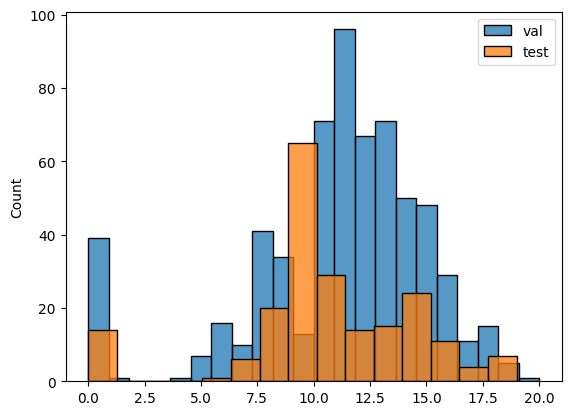

In [242]:
sns.histplot(model.predict(X_train), label='val')
sns.histplot(model.predict(X_test), label='test')
plt.legend()
plt.show()